In [55]:
import pandas as pd
import matplotlib.pyplot as plt

In [56]:
df = pd.read_csv("../Data/output.csv")

In [57]:
df.head()

,timestamp,level,user_id,action,latency_ms,error_code
0,2026-09-27 13:43:02,WARN,user_648,view_item,69,0
1,2026-09-27 13:43:03,INFO,user_188,view_item,41,0
2,2026-09-27 13:43:06,INFO,user_4,view_item,58,0
3,2026-09-27 13:43:07,INFO,user_524,pay,61,0
4,2026-09-27 13:43:10,INFO,user_30,pay,22,0


In [58]:
df["level"].value_counts()

level
INFO     894
ERROR     55
WARN      51
Name: count, dtype: int64

In [59]:
df["action"].value_counts()

action
view_item    257
add_cart     252
pay          250
login        241
Name: count, dtype: int64

In [60]:
df["latency_ms"].mean()

np.float64(91.973)

In [61]:
df["latency_ms"].median()

np.float64(60.0)

In [62]:
df["latency_ms"].max()

np.int64(1487)

In [63]:
df["latency_ms"].min()

np.int64(20)

In [64]:
df["latency_ms"].quantile(0.95)

np.float64(98.0)

In [65]:
df.groupby("action")["latency_ms"].agg(["mean", "max"])

,mean,max
action,,
add_cart,90.281746,1463
login,91.647303,1392
pay,92.188000,1486
view_item,93.727626,1487


In [66]:
error_quantity = (df["level"] == "ERROR").sum()
error_quantity / len(df)

np.float64(0.055)

In [67]:
slow_quantity = (df["latency_ms"] > 800).sum()
slow_quantity / len(df)

np.float64(0.03)

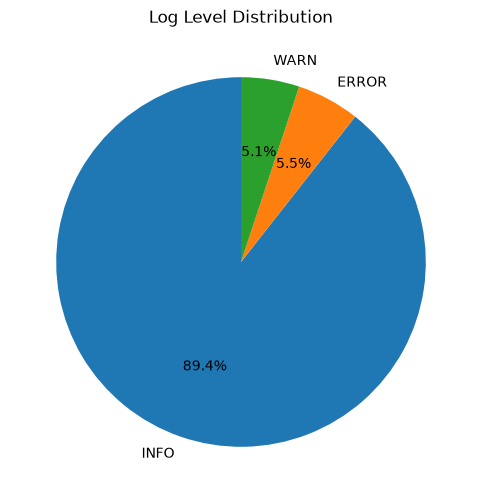

In [68]:
level_counts = df["level"].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(level_counts, labels=level_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Log Level Distribution")
plt.savefig("../Data/level_pie.png")
plt.show()

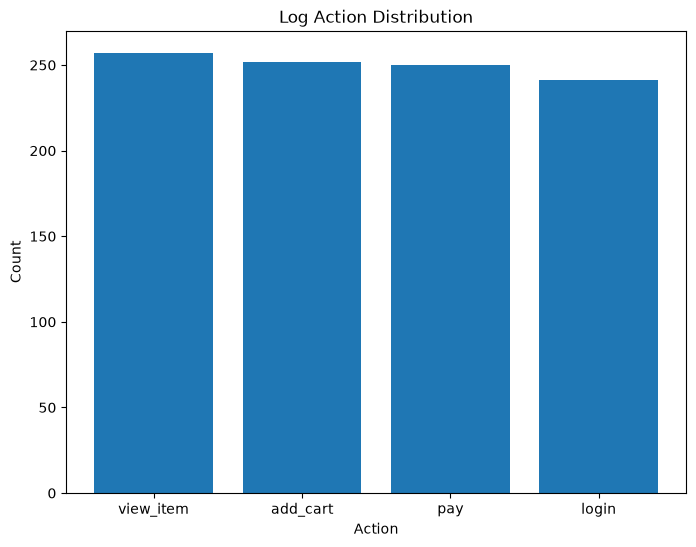

In [69]:
action_counts = df["action"].value_counts()
plt.figure(figsize=(8, 6))
plt.bar(action_counts.index, action_counts)
plt.xlabel("Action")
plt.ylabel("Count")
plt.title("Log Action Distribution")
plt.savefig("../Data/action_bar.png")
plt.show()

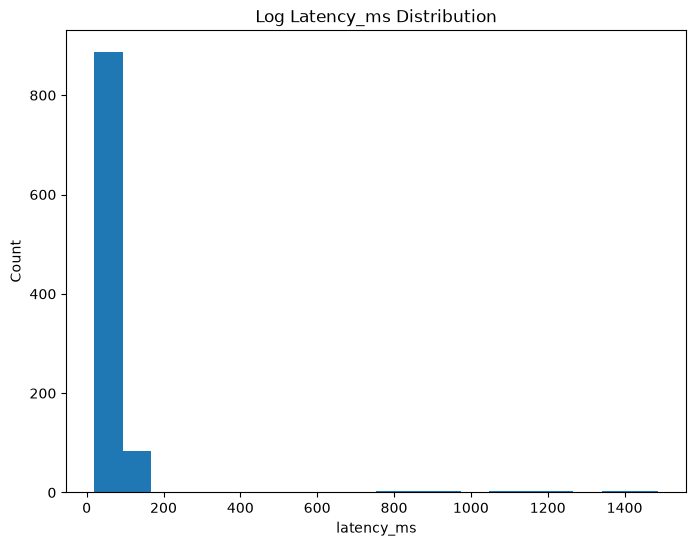

In [70]:
plt.figure(figsize=(8, 6))
plt.hist(df["latency_ms"], bins=20)
plt.xlabel("latency_ms")
plt.ylabel("Count")
plt.title("Log Latency_ms Distribution")
plt.savefig("../Data/latency_hist.png")
plt.show()

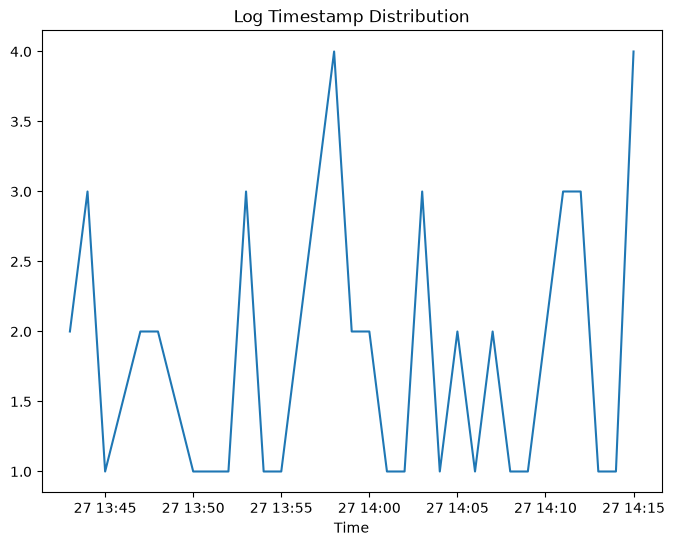

In [73]:
df["time"] = pd.to_datetime(df["timestamp"])
error_df = df[df["level"] == "ERROR"]
minute_counts = error_df.groupby(error_df["time"].dt.floor("min")).size()
plt.figure(figsize = (8, 6))
plt.plot(minute_counts.index, minute_counts.values)
plt.xlabel("Time")
plt.title("Log Timestamp Distribution")
plt.savefig("../Data/timestamp_error.png")
plt.show()